Kent Lin Chan

20202132

Se usó python 3.14.2

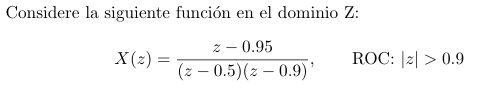

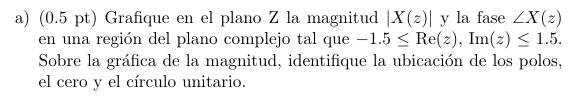

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from math import *
np.__version__

'2.4.4'

In [26]:
def X(z,cero,polo):
    """z: variable compleja, cero: lista de ceros, polo: lista de polos"""
    y=(z-cero[0])/((z-polo[0])*(z-polo[1]))
    return y

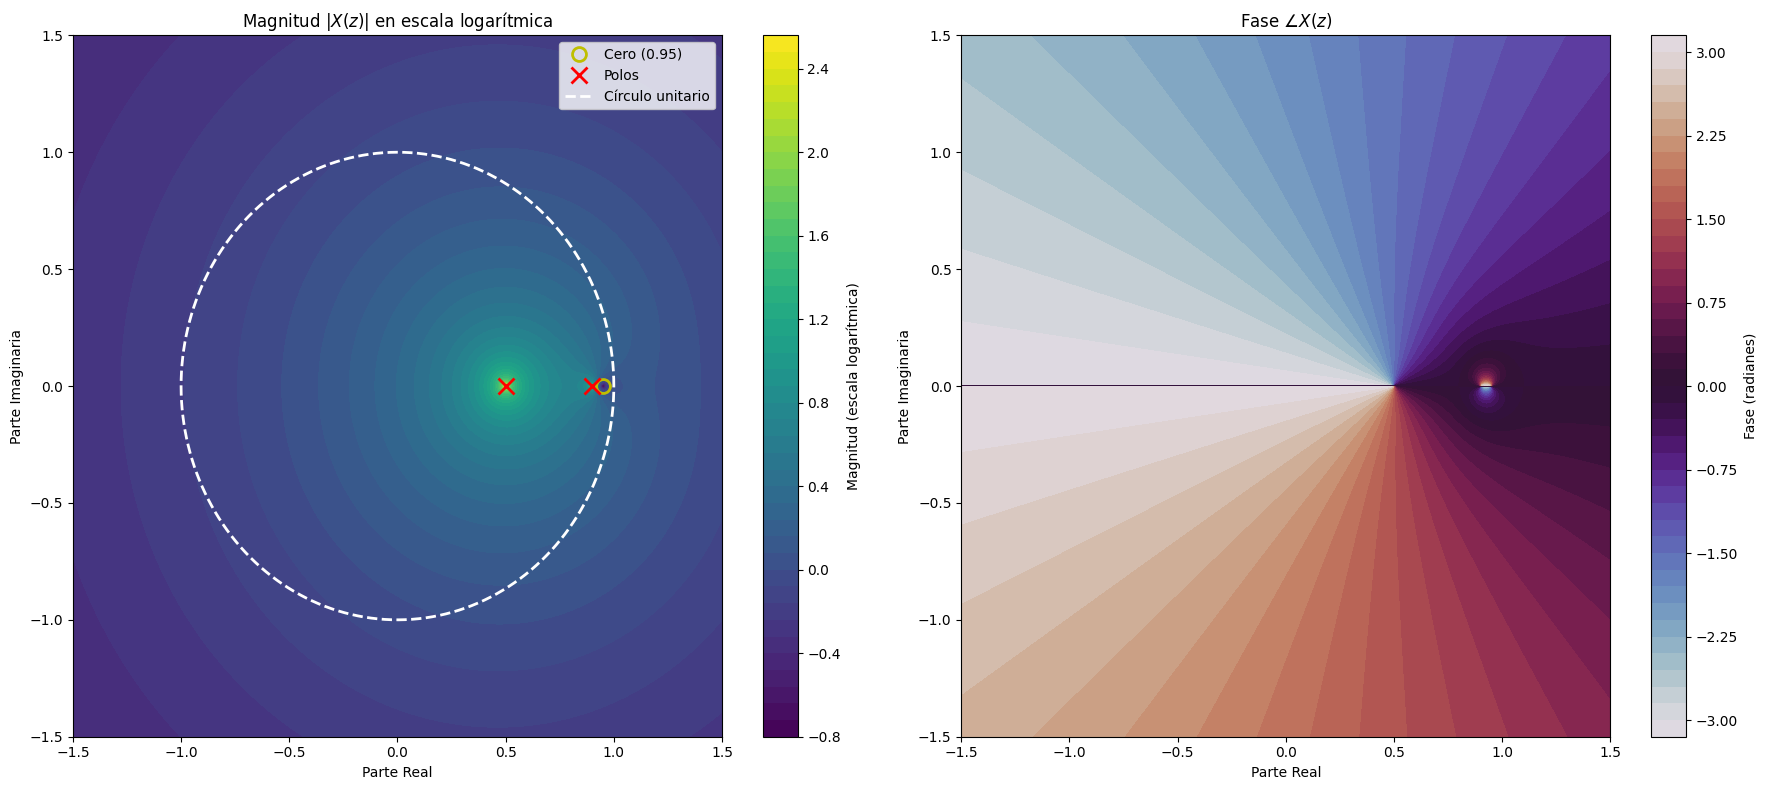

In [27]:
cero=[0.95]
polo=[0.5, 0.9]
real =np.linspace(-1.5,1.5,500)
imaginario = np.linspace(-1.5,1.5,500)
Real,Imaginario = np.meshgrid(real,imaginario)
Z = Real + 1j*Imaginario
X_Z = X(Z,cero,polo)

magnitud= np.abs(X_Z)
fase = np.angle(X_Z)

plt.figure(figsize=(18,8))
plt.subplot(1,2,1)

plt.contourf(Real,Imaginario,np.log10(magnitud),levels=50,cmap='viridis')
plt.colorbar(label='Magnitud (escala logarítmica)')

plt.plot(0.95, 0, 'yo', markersize=10, markerfacecolor='none', markeredgewidth=2, label='Cero (0.95)')
plt.plot([0.5, 0.9], [0, 0], 'rx', markersize=12, markeredgewidth=2, label='Polos')
theta = np.linspace(0, 2*np.pi, 1000)
plt.plot(np.cos(theta), np.sin(theta), 'w--', linewidth=2, label='Círculo unitario')
plt.xlim(-1.5, 1.5)
plt.ylim(-1.5, 1.5)

plt.legend(loc='upper right')

plt.title('Magnitud $|X(z)|$ en escala logarítmica')
plt.xlabel('Parte Real')
plt.ylabel('Parte Imaginaria')

plt.subplot(1,2,2)
plt.contourf(Real,Imaginario,fase,levels=50,cmap='twilight')
plt.colorbar(label='Fase (radianes)')
plt.xlim(-1.5, 1.5)
plt.ylim(-1.5, 1.5)

plt.title('Fase $\\angle X(z)$')
plt.xlabel('Parte Real')
plt.ylabel('Parte Imaginaria')

plt.tight_layout()
plt.show()


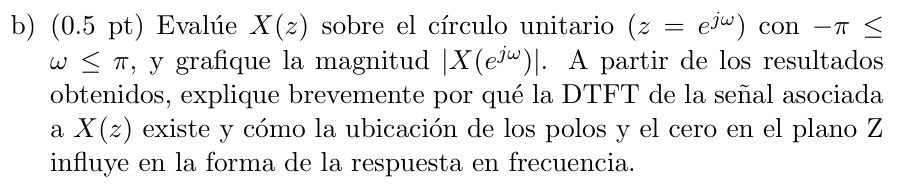

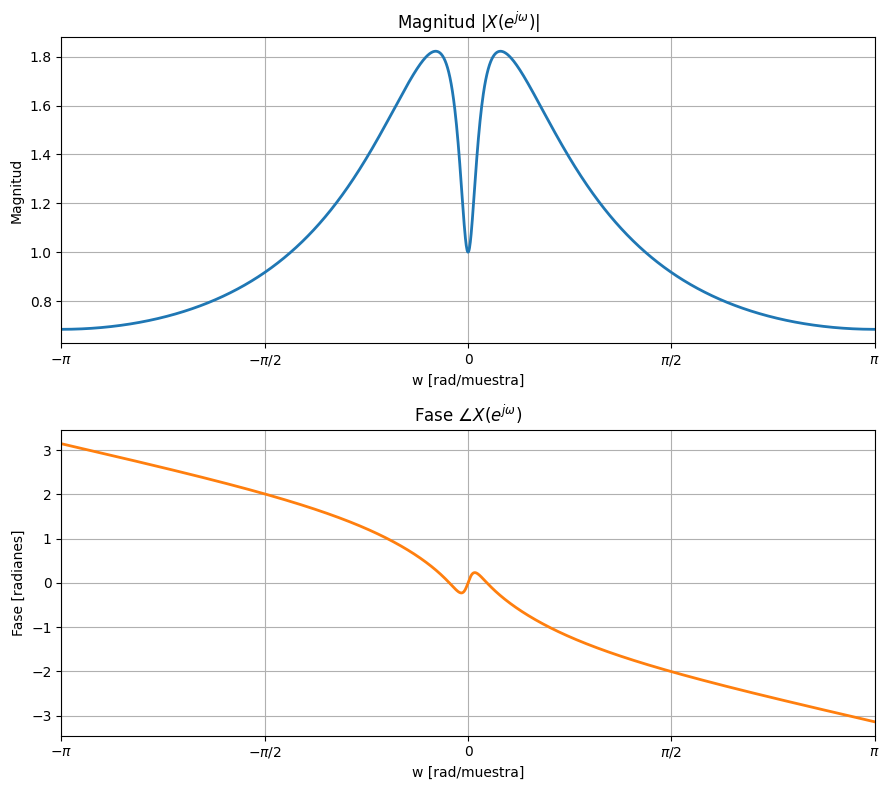

In [28]:
w = np.linspace(-np.pi, np.pi, 2000)
z = np.exp(1j * w)

X_unit = X(z, cero, polo)
mag_unit = np.abs(X_unit)
fase_unit = np.angle(X_unit)

plt.figure(figsize=(9, 8))

plt.subplot(2, 1, 1)
plt.plot(w, mag_unit, linewidth=2, color='tab:blue')
plt.title('Magnitud $|X(e^{j\\omega})|$')
plt.xlabel('w [rad/muestra]')
plt.ylabel('Magnitud')
plt.xlim([-np.pi, np.pi])
plt.grid(True)
plt.xticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi], 
           ['$-\\pi$', '$-\\pi/2$', '0', '$\\pi/2$', '$\\pi$'])

plt.subplot(2, 1, 2)
plt.plot(w, fase_unit, linewidth=2, color='tab:orange')
plt.title('Fase $\\angle X(e^{j\\omega})$')
plt.xlabel('w [rad/muestra]')
plt.ylabel('Fase [radianes]')
plt.xlim([-np.pi, np.pi])
plt.grid(True)
plt.xticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi], 
           ['$-\\pi$', '$-\\pi/2$', '0', '$\\pi/2$', '$\\pi$'])

plt.tight_layout()
plt.show()

La DTFT de la señal asociada a X(z) existe porque lo evaluamos sobre el círculo unitario (|z| = 1), donde la región de convergencia (ROC) incluye este círculo. Los polos están en 0.5 y 0.9, ambos dentro del círculo unitario (|z| < 1), por lo tanto, el círculo unitario está fuera de los polos y la transformada converge.
Hay cero en z = 0.95, lo que provoca un mínimo en la magnitud de w=0 (cuando z es 1). Por eso se observa el valle en el centro de la gráfica.
Hay polos en z=0.5 z=0.9. Cuando más cerca está un polo del círculo unitario, mayor es el pico en la magnitud en frecuencias cercanas. Como ambos polos están dentro del círculo pero a diferentes distancias, el polo z=0.9 produce un pico más pronunciado que el polo z=0.5.
